In [1]:
import pandas as pd
import sys                          
import numpy as np             # Data manipulation 
from sklearn.decomposition import PCA        # The main algorithm
from matplotlib import pyplot as plt         # Graphing
import seaborn as sns                        # Graphing
from collections import defaultdict, Counter # Utils
sns.set(style="white")                       # Tuning the style of charts
import warnings                              # Disable some warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

In [2]:
data_factorySolarGen = pd.read_csv('Generacion_fotovoltaica.csv')
data_gridInput = pd.read_csv('Consumo.csv')
data_Weather = pd.read_csv('Meteorologia.csv')
data_CarbonIntensity23 = pd.read_csv('ES_2023_hourly.csv')
data_CarbonIntensity24 = pd.read_csv('ES_2024_hourly.csv')
data_CarbonIntensity = pd.concat([data_CarbonIntensity23, data_CarbonIntensity24], ignore_index=True)
data_factorySolarUse = pd.read_csv('Consumo_fotovoltaica.csv')

data_CDM2023 = pd.read_csv('ComunidadData/2023.csv',delimiter=';')
data_CDM2023 = data_CDM2023.drop(columns=data_CDM2023.filter(regex=r'^v\d{2}$').columns)
data_CDM2023 = data_CDM2023.drop(columns=['punto_muestreo'])

data_CDM2023 = data_CDM2023[data_CDM2023['magnitud']==89]

data_CDM2023

,provincia,municipio,estacion,magnitud,ano,mes,dia,h01,h02,h03,...,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24
6,28,102,1,89,2023,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,28,120,1,89,2023,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,"0,1"
20,28,123,2,89,2023,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27,28,13,2,89,2023,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34,28,133,2,89,2023,1,1,0,0,0,...,0,0,0,0,0,0,0,0,"0,2",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68884,28,7,4,89,2023,12,31,0,0,0,...,0,0,0,0,0,0,0,0,0,0
68891,28,74,7,89,2023,12,31,0,0,0,...,0,0,0,0,0,0,0,0,0,0
68898,28,80,3,89,2023,12,31,0,0,0,...,0,0,0,0,0,0,0,0,0,0
68905,28,9,1,89,2023,12,31,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
def renameAndIndex(df,datetime):
    df=df.rename(columns={datetime:'TIMESTAMP'})
    df['TIMESTAMP']=pd.to_datetime(df['TIMESTAMP'])
    df.set_index('TIMESTAMP', inplace=True)
    return df

In [4]:
data_factorySolarGen = renameAndIndex(data_factorySolarGen,'FECHA')
data_gridInput = renameAndIndex(data_gridInput,'FECHA')
data_Weather = renameAndIndex(data_Weather,'FORECAST_TIMESTAMP')
data_CarbonIntensity = renameAndIndex(data_CarbonIntensity,'Datetime (UTC)')
data_factorySolarUse = renameAndIndex(data_factorySolarUse,'FECHA')

In [5]:
allDatasets = {
    "factorySolarGen": data_factorySolarGen,
    "gridInput": data_gridInput,
    "weather": data_Weather,
    "carbonIntensity": data_CarbonIntensity,
    "factorySolarUse": data_factorySolarUse
}

minMaxDates = {}
for name, dataset in allDatasets.items():
    min_date = dataset.index.min()
    max_date = dataset.index.max()
    dataLen = len(dataset)
    minMaxDates[name] = {"min": min_date, "max": max_date, "rows":dataLen}

timeframes = pd.DataFrame(minMaxDates)

timeframes


,factorySolarGen,gridInput,weather,carbonIntensity,factorySolarUse
min,2023-07-24 11:00:00,2023-07-24 11:00:00,2023-07-24 11:00:00+00:00,2023-01-01 00:00:00,2024-09-01 00:00:00+02:00
max,2024-08-31 23:00:00,2024-08-31 23:00:00,2024-10-31 23:00:00+00:00,2024-12-31 23:00:00,2024-10-17 23:00:00+02:00
rows,9708,9708,100557,17544,1128


In [6]:
coords = data_Weather[['LATITUDE', 'LONGITUDE']].drop_duplicates().values.tolist()
repsolPintoCoords = [40.265468,-3.738145]

coords.append(repsolPintoCoords)
import folium

# Center map roughly on the middle point
center_lat = sum([lat for lat, _ in coords]) / len(coords)
center_lon = sum([lon for _, lon in coords]) / len(coords)

m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# Add all points to map
for i, (lat, lon) in enumerate(coords):
    folium.Marker(
        location=[lat, lon],
        popup=f'Point {i+1}',
        icon=folium.Icon(color='red')
    ).add_to(m)

# Save to file
m.save("grid_points_map.html")


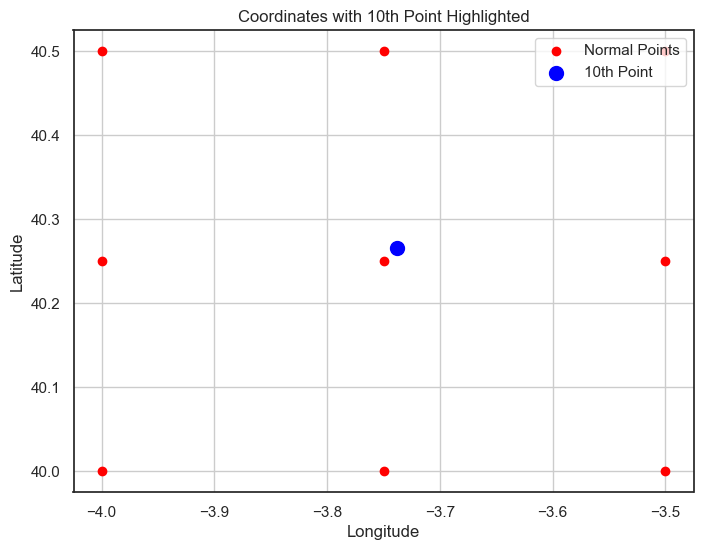

In [7]:
coords = data_Weather[['LATITUDE', 'LONGITUDE']].drop_duplicates().values.tolist()
coords

# Since the weather data is collected from 9 distinct points, according to the EDA, we can average these 9 points to get an accurate reading, as we don't know exact factory location

data_Weather.groupby('TIMESTAMP').mean()

coords.append(repsolPintoCoords)

normal = coords[:-1]
special = coords[-1:]

plt.figure(figsize=(8, 6))

# Normal points in red
plt.scatter([lon for _, lon in normal], [lat for lat, _ in normal], color='red', label='Normal Points')

# Special point in blue
plt.scatter(special[0][1], special[0][0], color='blue', s=100, label='10th Point')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Coordinates with 10th Point Highlighted')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
from geopy.distance import geodesic  # accurate distance calculation

grid_coords = coords
target_coord = repsolPintoCoords

distances = [geodesic(coord, target_coord).kilometers for coord in grid_coords]

inv_distances = [1/d if d != 0 else 1e9 for d in distances]  # Avoid division by zero
total = sum(inv_distances)
weights = [w/total for w in inv_distances]

point_names = [f"point{i+1}" for i in range(len(grid_coords))]
weight_mapping = dict(zip(point_names, weights))

In [9]:
point_labels = [f"point{i+1}" for i in range(len(coords))]

coord_to_label = {tuple(coord): label for coord, label in zip(coords, point_labels)}

data_Weather['point'] = data_Weather[['LATITUDE', 'LONGITUDE']].apply(
    lambda row: coord_to_label.get((row['LATITUDE'], row['LONGITUDE']), None),
    axis=1
)

data_Weather['weight'] = data_Weather['point'].map(weight_mapping)

columns_to_weight = [col for col in data_Weather.columns if col not in ['LATITUDE', 'LONGITUDE','point']]

for col in columns_to_weight:
    data_Weather[col] = data_Weather[col] * data_Weather['weight']

data_Weather = data_Weather.drop(columns=['point','weight','LATITUDE','LONGITUDE'])

data_Weather = data_Weather.groupby('TIMESTAMP').sum()

data_Weather.index = data_Weather.index.tz_convert(None)

data_Weather

,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,dswrfsurface_0,gustsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00,4.665590e-09,2.185505e-09,1.365062e-08,3.603170e-12,2.362482e-07,0.000014,2.351101e-07,2.501354e-07,4.463244e-07,5.866172e-09,...,0.000074,2.541219e-09,2.341094e-07,2.362843e-07,2.292143e-07,2.542979e-07,0.000000e+00,2.474308e-07,5.333843e-09,2.265897e-09
2023-07-24 12:00:00,4.938432e-09,2.771714e-09,1.353187e-08,3.820398e-12,2.371825e-07,0.000017,2.357676e-07,2.531983e-07,4.976726e-07,6.530922e-09,...,0.000074,2.843015e-09,2.349677e-07,2.372378e-07,2.292143e-07,2.550379e-07,0.000000e+00,2.488758e-07,5.708619e-09,2.903948e-09
2023-07-24 13:00:00,5.392882e-09,2.958614e-09,1.344588e-08,4.061002e-12,2.381012e-07,0.000003,2.365012e-07,2.756006e-07,7.675623e-07,6.965488e-09,...,0.000074,3.125486e-08,2.358297e-07,2.380798e-07,2.372110e-07,2.553476e-07,0.000000e+00,2.492625e-07,6.314422e-09,3.139477e-09
2023-07-24 14:00:00,6.171356e-09,2.814299e-09,1.338326e-08,4.239048e-12,2.387294e-07,0.000006,2.370619e-07,2.789081e-07,7.498946e-07,7.724058e-09,...,0.000073,9.298669e-09,2.365362e-07,2.387397e-07,2.372110e-07,2.559348e-07,0.000000e+00,2.485842e-07,7.279874e-09,3.030383e-09
2023-07-24 15:00:00,6.446488e-09,3.007603e-09,1.366349e-08,4.452215e-12,2.391054e-07,0.000008,2.374704e-07,2.812251e-07,7.188519e-07,8.209820e-09,...,0.000073,5.200030e-08,2.371651e-07,2.391334e-07,2.372110e-07,2.587872e-07,0.000000e+00,2.473158e-07,7.617130e-09,3.355642e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31 19:00:00,2.524516e-09,-2.672555e-10,6.189470e-08,6.626956e-12,2.250466e-07,0.000000,2.250529e-07,2.482590e-07,0.000000e+00,3.849244e-09,...,0.000074,1.694244e-08,2.251265e-07,2.263915e-07,2.248394e-07,2.313339e-07,4.223237e-12,2.246422e-07,3.697921e-09,-2.148929e-10
2024-10-31 20:00:00,1.668070e-09,1.167933e-10,6.092895e-08,6.621885e-12,2.251731e-07,0.000000,2.251636e-07,2.462847e-07,0.000000e+00,2.149862e-09,...,0.000074,3.150138e-08,2.253799e-07,2.264303e-07,2.246216e-07,2.317543e-07,4.223237e-12,2.245161e-07,2.492672e-09,2.352438e-10
2024-10-31 21:00:00,1.305453e-09,1.435080e-10,6.070317e-08,6.602280e-12,2.251852e-07,0.000000,2.252034e-07,2.490108e-07,0.000000e+00,1.813621e-09,...,0.000074,6.713375e-08,2.252899e-07,2.265012e-07,2.245452e-07,2.313939e-07,4.223237e-12,2.243252e-07,1.984150e-09,2.479843e-10


In [10]:
data_All = pd.concat([
    data_Weather.add_prefix("W_"),
    data_factorySolarGen.add_prefix("SG_"),
    data_gridInput.add_prefix("GI_"),
], axis=1, join='outer')

In [11]:
data_All.to_csv('cleaned_data.csv')

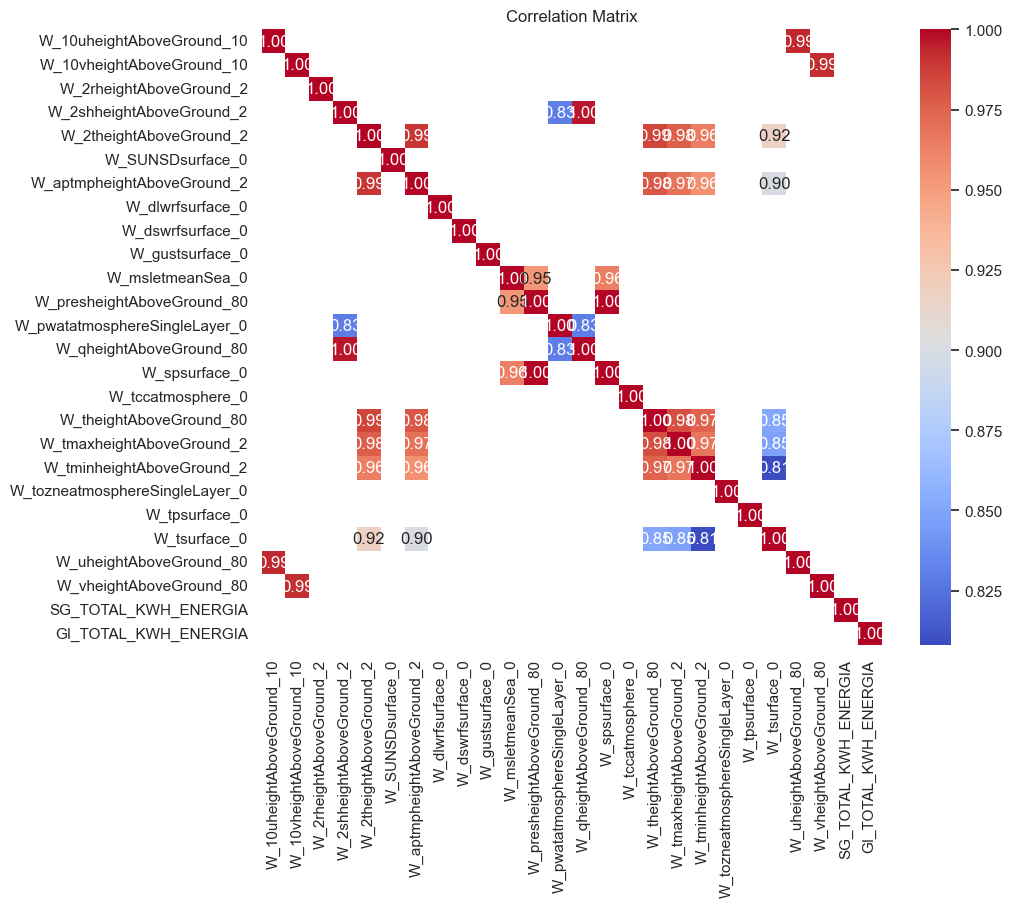

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = data_All.corr()
filtered_corr = correlation_matrix[correlation_matrix.abs() > 0.8]
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [13]:
data_All.drop(columns=[])

,W_10uheightAboveGround_10,W_10vheightAboveGround_10,W_2rheightAboveGround_2,W_2shheightAboveGround_2,W_2theightAboveGround_2,W_SUNSDsurface_0,W_aptmpheightAboveGround_2,W_dlwrfsurface_0,W_dswrfsurface_0,W_gustsurface_0,...,W_theightAboveGround_80,W_tmaxheightAboveGround_2,W_tminheightAboveGround_2,W_tozneatmosphereSingleLayer_0,W_tpsurface_0,W_tsurface_0,W_uheightAboveGround_80,W_vheightAboveGround_80,SG_TOTAL_KWH_ENERGIA,GI_TOTAL_KWH_ENERGIA
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00,4.665590e-09,2.185505e-09,1.365062e-08,3.603170e-12,2.362482e-07,0.000014,2.351101e-07,2.501354e-07,4.463244e-07,5.866172e-09,...,2.341094e-07,2.362843e-07,2.292143e-07,2.542979e-07,0.000000e+00,2.474308e-07,5.333843e-09,2.265897e-09,NaN,506.012634
2023-07-24 12:00:00,4.938432e-09,2.771714e-09,1.353187e-08,3.820398e-12,2.371825e-07,0.000017,2.357676e-07,2.531983e-07,4.976726e-07,6.530922e-09,...,2.349677e-07,2.372378e-07,2.292143e-07,2.550379e-07,0.000000e+00,2.488758e-07,5.708619e-09,2.903948e-09,115.66,456.551453
2023-07-24 13:00:00,5.392882e-09,2.958614e-09,1.344588e-08,4.061002e-12,2.381012e-07,0.000003,2.365012e-07,2.756006e-07,7.675623e-07,6.965488e-09,...,2.358297e-07,2.380798e-07,2.372110e-07,2.553476e-07,0.000000e+00,2.492625e-07,6.314422e-09,3.139477e-09,129.98,395.318604
2023-07-24 14:00:00,6.171356e-09,2.814299e-09,1.338326e-08,4.239048e-12,2.387294e-07,0.000006,2.370619e-07,2.789081e-07,7.498946e-07,7.724058e-09,...,2.365362e-07,2.387397e-07,2.372110e-07,2.559348e-07,0.000000e+00,2.485842e-07,7.279874e-09,3.030383e-09,134.35,330.052979
2023-07-24 15:00:00,6.446488e-09,3.007603e-09,1.366349e-08,4.452215e-12,2.391054e-07,0.000008,2.374704e-07,2.812251e-07,7.188519e-07,8.209820e-09,...,2.371651e-07,2.391334e-07,2.372110e-07,2.587872e-07,0.000000e+00,2.473158e-07,7.617130e-09,3.355642e-09,133.90,183.146606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31 19:00:00,2.524516e-09,-2.672555e-10,6.189470e-08,6.626956e-12,2.250466e-07,0.000000,2.250529e-07,2.482590e-07,0.000000e+00,3.849244e-09,...,2.251265e-07,2.263915e-07,2.248394e-07,2.313339e-07,4.223237e-12,2.246422e-07,3.697921e-09,-2.148929e-10,NaN,NaN
2024-10-31 20:00:00,1.668070e-09,1.167933e-10,6.092895e-08,6.621885e-12,2.251731e-07,0.000000,2.251636e-07,2.462847e-07,0.000000e+00,2.149862e-09,...,2.253799e-07,2.264303e-07,2.246216e-07,2.317543e-07,4.223237e-12,2.245161e-07,2.492672e-09,2.352438e-10,NaN,NaN
2024-10-31 21:00:00,1.305453e-09,1.435080e-10,6.070317e-08,6.602280e-12,2.251852e-07,0.000000,2.252034e-07,2.490108e-07,0.000000e+00,1.813621e-09,...,2.252899e-07,2.265012e-07,2.245452e-07,2.313939e-07,4.223237e-12,2.243252e-07,1.984150e-09,2.479843e-10,NaN,NaN


## Principal Component Analysis

### Null Imputation

In [14]:
import numpy as np

numerical_columns = list(data_All.select_dtypes(include=[np.number]).columns)

impute = True # you can change this

if impute:
    # Use mean for numerical features
    for feature in data_All:
        v = data_All[feature].mean()
        if np.isnan(v):
            v = 0
        print("Filling %s with %s" % (feature, v))
        data_All[feature] = data_All[feature].fillna(v)

else:        
    # drop records
    data_All.dropna(inplace=True)

Filling W_10uheightAboveGround_10 with 1.1153698045238243e-09
Filling W_10vheightAboveGround_10 with 3.5738190280577296e-10
Filling W_2rheightAboveGround_2 with 4.0471752744949126e-08
Filling W_2shheightAboveGround_2 with 5.012134937143563e-12
Filling W_2theightAboveGround_2 with 2.2774118296290372e-07
Filling W_SUNSDsurface_0 with 4.796496542201377e-06
Filling W_aptmpheightAboveGround_2 with 2.2716289912287283e-07
Filling W_dlwrfsurface_0 with 2.542100297225383e-07
Filling W_dswrfsurface_0 with 1.6068543848687974e-07
Filling W_gustsurface_0 with 4.500829009892144e-09
Filling W_msletmeanSea_0 with 7.950818236605081e-05
Filling W_presheightAboveGround_80 with 7.320274232116104e-05
Filling W_pwatatmosphereSingleLayer_0 with 1.3415359920212683e-08
Filling W_qheightAboveGround_80 with 4.864965073409876e-12
Filling W_spsurface_0 with 7.388965456440728e-05
Filling W_tccatmosphere_0 with 3.54290033598011e-08
Filling W_theightAboveGround_80 with 2.2759675731169898e-07
Filling W_tmaxheightAbove

In [15]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler().fit(data_All)
X_std = ss.transform(data_All)

#### Compute PCA

In [16]:
sklearn_pca = PCA()
Y_sklearn = sklearn_pca.fit_transform(X_std)

#### Eigenvector Explained Variance

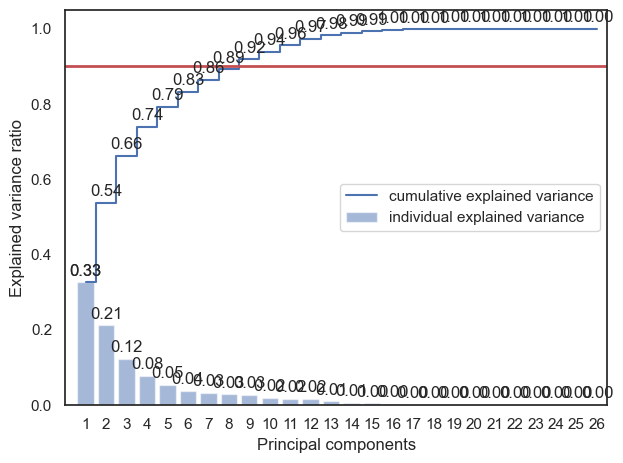

In [17]:
plt.bar(range(1,sklearn_pca.n_components_+1), sklearn_pca.explained_variance_ratio_, alpha=0.5, align='center',label='individual explained variance')
plt.step(range(1,sklearn_pca.n_components_+1), [sklearn_pca.explained_variance_ratio_[:y].sum() for y in range(1,sklearn_pca.n_components_+1)], where='mid',label='cumulative explained variance')
plt.axhline(y=0.90, linewidth=2, color = 'r')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
for i, ratio in enumerate(sklearn_pca.explained_variance_ratio_):
    plt.text(i+1, ratio + 0.01, f'{ratio:.2f}', ha='center', va='bottom')
for i, ratio in enumerate([sklearn_pca.explained_variance_ratio_[:y].sum() for y in range(1,sklearn_pca.n_components_+1)]):
    plt.text(i+1, ratio + 0.01, f'{ratio:.2f}', ha='center', va='bottom')

plt.xlim([0, sklearn_pca.n_components_+0.5])
plt.xticks(range(1, sklearn_pca.n_components_ + 1))
plt.legend(loc='best')
plt.tight_layout()

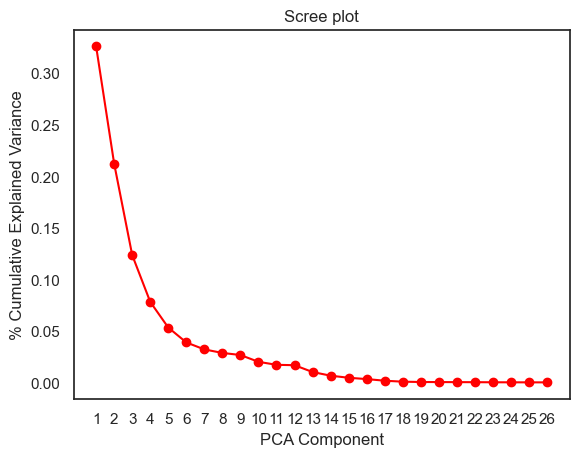

In [18]:
# Scree plot 
plt.plot(
    range(1,len(sklearn_pca.explained_variance_ratio_ )+1),
    sklearn_pca.explained_variance_ratio_,
    c='red', marker='o'
)
plt.xticks(range(1, len(sklearn_pca.explained_variance_ratio_) + 1))   
plt.xlabel('PCA Component')
plt.ylabel('% Cumulative Explained Variance')
plt.title('Scree plot')
plt.show()

In [19]:
VARIANCE_TO_KEEP = 0.85 # that would mean two componentes in our example
keep_recommend = [sklearn_pca.explained_variance_ratio_[:y].sum()>VARIANCE_TO_KEEP for y in range(1,sklearn_pca.n_components_+1)].count(False)
print("Number of components to keep to retain %s%% of the variance:" % (100*VARIANCE_TO_KEEP), keep_recommend, "out of the original", sklearn_pca.n_components_)
n_components = keep_recommend

Number of components to keep to retain 85.0% of the variance: 6 out of the original 26


In [20]:
sklearn_pca_final = PCA(n_components)
Y_sklearn = sklearn_pca_final.fit_transform(X_std)

In [21]:
# Shows Factor loadings = correlations between variables and factors
print ("")
print ("Factor loadings:")

pd.set_option('display.float_format', '{:.4f}'.format)

dfloadings=pd.DataFrame(
    data    = sklearn_pca_final.components_,
    columns = data_All.columns,
)

index_list=[]
for n in range(n_components):
    index_list.append("PC"+str(n+1))

dfloadings.index = index_list

# Hide low values so that it is clearer
dfloadings.T.where(abs(dfloadings.T) > 0.3  , "")  # we hide values lower than 0.25 to better display the relations


Factor loadings:


,PC1,PC2,PC3,PC4,PC5,PC6
W_10uheightAboveGround_10,,,,,,-0.3831
W_10vheightAboveGround_10,,,,0.3416,,0.4309
W_2rheightAboveGround_2,,,,,,
W_2shheightAboveGround_2,,,0.3708,,,
W_2theightAboveGround_2,0.3348,,,,,
W_SUNSDsurface_0,,,,,0.3101,
W_aptmpheightAboveGround_2,0.3322,,,,,
W_dlwrfsurface_0,,,,,,
W_dswrfsurface_0,,,-0.3119,,,
W_gustsurface_0,,-0.3126,,,,


#### Communalities

In [22]:
# Communalities
commun=[]

for col in dfloadings.columns:
    commun.append((dfloadings.iloc[0:3][col]**2).sum())
    
dfcommun = pd.DataFrame(commun,index=dfloadings.columns, columns=["Communalities"])
dfcommun.sort_values("Communalities", ascending=False)

,Communalities
W_qheightAboveGround_80,0.1993
W_2shheightAboveGround_2,0.1954
W_pwatatmosphereSingleLayer_0,0.1696
W_10uheightAboveGround_10,0.1479
W_2rheightAboveGround_2,0.1449
W_uheightAboveGround_80,0.1441
W_dswrfsurface_0,0.1417
W_presheightAboveGround_80,0.1409
W_spsurface_0,0.1397
W_msletmeanSea_0,0.1324


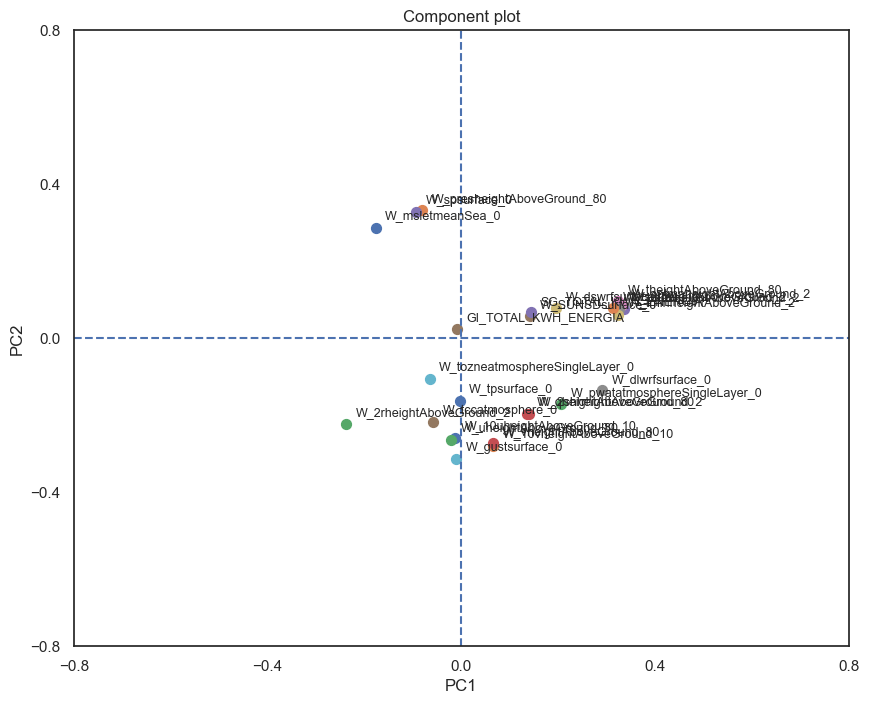

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Get the loadings of x and y axes
dfloadT = dfloadings.T

xs = dfloadT.PC1
ys = dfloadT.PC2
 
plt.figure(figsize=(10, 8))
plt.axvline(x=0, color='b', linestyle='dashed')
plt.axhline(y=0, color='b', linestyle='dashed')

# Plot the loadings on a scatterplot
for i, varnames in enumerate(dfloadings.columns):
    plt.scatter(xs.iloc[i], ys.iloc[i], s=50)
    
    # Slightly offset the text to avoid overlap
    plt.text(xs.iloc[i] + 0.02, ys.iloc[i] + 0.02, varnames, fontsize=9)

# Define the axes and show plot
xticks = np.linspace(-0.8, 0.8, num=5)
yticks = np.linspace(-0.8, 0.8, num=5)
plt.xticks(xticks)
plt.yticks(yticks)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Component plot')

# Save the plot and show it
plt.savefig('Component_plot.png', bbox_inches='tight')  # Avoid cutting parts off
plt.show()